# Neuronal Models Part 1: Follow Up
Some remarks on the previously done experiments, we're going to change some stuff to do some remarks

In [2]:
import numpy as np 
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import torch 
from torch import nn, optim
from torchdiffeq import odeint

In [80]:
def firing_rate_threshold(t, data, T, I_ext, J):
    x = data[0]
    activation = np.maximum(0, I_ext(t)+J*x -T)
    return [-x + activation]


## Experiment 1:

Redo the experiment 1. from before, but lowering the threshold to an almost-zero value

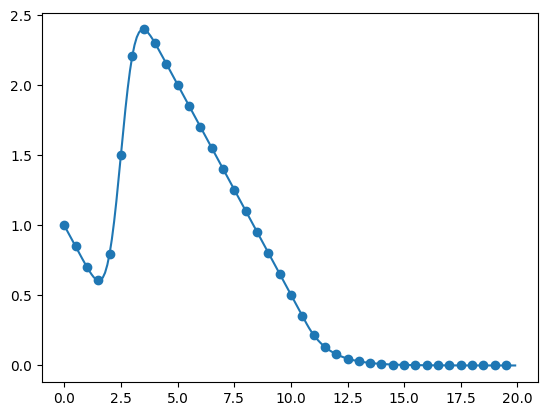

In [88]:
def I(t, t_peak, sigma):
    return 2.0 * np.exp(-((t - t_peak)**2) / (2 * sigma**2)) 
    
T_max = 20

sol = solve_ivp(
    firing_rate_threshold, 
    [0, T_max], (x0:=1.,), args=(0.3, lambda t: I(t, 2.5, 0.5), 1), t_eval=np.arange(0, T_max, 0.1),
    rtol = 1e-8, atol=1e-8)

plt.plot(sol.t, sol.y[0])

X_train = sol.y[0][::5]
T_train = sol.t[::5]

plt.scatter(T_train, X_train)

plt.show()

In [89]:
class my_universal_neuron(nn.Module):
    def __init__(self, transfer, threshold, strength):
        super().__init__()

        self.transfer = transfer # N.B. TRANSFER HAS TO WORK ON TENSORS!!!!!!!!
        self.register_buffer("threshold", torch.as_tensor(threshold, dtype=torch.float32))
        self.register_buffer("strength", torch.as_tensor(strength, dtype=torch.float32))

        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.Tanh(),
            nn.Linear(16, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 16),
            nn.Tanh(),
            nn.Linear(16, 1),
            nn.Softplus()
        )


    def forward(self, t, x):
        external_impulse = self.net(t.reshape(1,1))

        return -x + self.transfer(external_impulse + self.strength * x, self.threshold)
    
def transfer_threshold(I, T):
    return torch.maximum(
        torch.tensor([0.], requires_grad=True),
        I-T
    )

def fake_threshold(I, T):
    return torch.nn.functional.softplus(10 * (I - T)) / 10

In [91]:
from tqdm import tqdm 

my_monkey = my_universal_neuron(
    fake_threshold, torch.tensor([0.3]), torch.tensor([1.])
)

print(my_monkey.threshold)

lr = 0.01
optimizer = optim.Adam(my_monkey.parameters(), lr=lr)

n_epochs = 2000
rtol = 1e-7

t_train_torch = torch.tensor(T_train, dtype=torch.float32)
x0_torch = torch.tensor([x0], dtype=torch.float32, requires_grad=True)
x_train_torch = torch.tensor(X_train, dtype=torch.float32).view(-1, 1)
losses = []

for EPOCH in (range(n_epochs)):
    optimizer.zero_grad()
    my_monkey.zero_grad()
    
    # forward solution
    x_pred = odeint(my_monkey, 
                    x0_torch,
                    t_train_torch,
                    method="rk4",
                    )
    
    # Compute loss at training points
    loss = torch.mean((x_pred-x_train_torch)**2)
    
    # Backpropagate
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {EPOCH}: MSE Loss = {loss.item():.4e}")
    losses.append(loss.item())


print(losses[-1])

tensor([0.3000])
Epoch 0: MSE Loss = 3.9343e+01
Epoch 1: MSE Loss = 1.8799e+01
Epoch 2: MSE Loss = 7.7769e+00
Epoch 3: MSE Loss = 1.6179e+00
Epoch 4: MSE Loss = 3.8503e-01
Epoch 5: MSE Loss = 6.4188e-01
Epoch 6: MSE Loss = 7.7301e-01
Epoch 7: MSE Loss = 8.3489e-01
Epoch 8: MSE Loss = 8.6832e-01
Epoch 9: MSE Loss = 8.8838e-01
Epoch 10: MSE Loss = 9.0138e-01
Epoch 11: MSE Loss = 9.1029e-01
Epoch 12: MSE Loss = 9.1666e-01
Epoch 13: MSE Loss = 9.2135e-01
Epoch 14: MSE Loss = 9.2489e-01
Epoch 15: MSE Loss = 9.2759e-01
Epoch 16: MSE Loss = 9.2967e-01
Epoch 17: MSE Loss = 9.3127e-01
Epoch 18: MSE Loss = 9.3250e-01
Epoch 19: MSE Loss = 9.3342e-01
Epoch 20: MSE Loss = 9.3408e-01
Epoch 21: MSE Loss = 9.3454e-01
Epoch 22: MSE Loss = 9.3481e-01
Epoch 23: MSE Loss = 9.3492e-01
Epoch 24: MSE Loss = 9.3488e-01
Epoch 25: MSE Loss = 9.3472e-01
Epoch 26: MSE Loss = 9.3444e-01
Epoch 27: MSE Loss = 9.3404e-01
Epoch 28: MSE Loss = 9.3353e-01
Epoch 29: MSE Loss = 9.3291e-01
Epoch 30: MSE Loss = 9.3219e-01
E

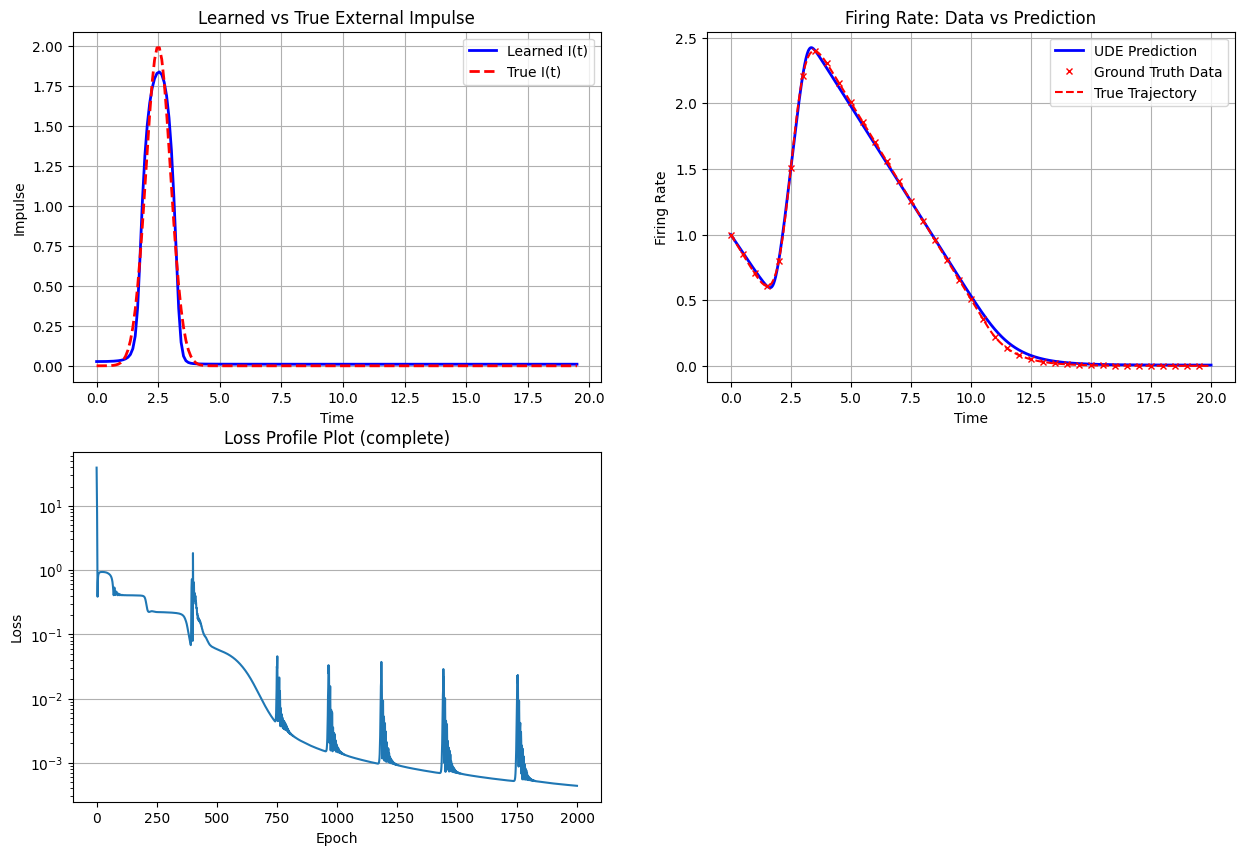

In [94]:
# Plot the learned impulse function
t_plot = torch.linspace(0, T_train[-1], 200)
with torch.no_grad():
    I_learned = torch.stack([my_monkey.net(torch.tensor([[t]], dtype=torch.float32)) 
                             for t in t_plot]).squeeze()

plt.figure(figsize=(15, 10))

# Plot 1: Learned impulse vs true impulse
plt.subplot(2, 2, 1)
plt.plot(t_plot.numpy(), I_learned.numpy(), 'b-', linewidth=2, label='Learned I(t)')
t_true = np.linspace(0, T_train[-1], 200)
I_true = np.array([I(t, 2.5, 0.5) for t in t_true])
plt.plot(t_true, I_true, 'r--', linewidth=2, label='True I(t)')
plt.xlabel('Time')
plt.ylabel('Impulse')
plt.title('Learned vs True External Impulse')
plt.legend()
plt.grid()

# Plot 2: Predictions vs data
plt.subplot(2, 2, 2)
x_pred = odeint(my_monkey, 
                torch.tensor([X_train[0]], dtype=torch.float32).unsqueeze(1),
                T_eval := torch.arange(0,20, 0.01))
plt.plot(T_eval.detach().numpy(), x_pred.detach().numpy().squeeze(), 'b-', linewidth=2, label='UDE Prediction')
plt.plot(T_train, X_train, 'xr', markersize=4, label='Ground Truth Data')
plt.plot(sol.t, sol.y[0], color="red", linestyle="--", label="True Trajectory")

plt.xlabel('Time')
plt.ylabel('Firing Rate')
plt.legend()
plt.title('Firing Rate: Data vs Prediction')
plt.grid()

# Plot 3: losses with semilogy
losses_data = np.array(losses)

plt.subplot(2, 2, 3)
plt.semilogy(range(len(losses_data)), losses_data)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Profile Plot (complete)")

plt.grid(axis='y')

plt.show()



In [95]:
torch.save(my_monkey.state_dict(), "./models_weights/monkey_1_followup.dinomeng")

As can see, the shape of the learnt transfer fits better (although not perfectly, but this is rather a training problem than an identifiabiliy problem per se), which kinda confirms our hunch about the transfer treshold

## Experiment 3: Enforce non negativity constraint to fix everything (or try to)

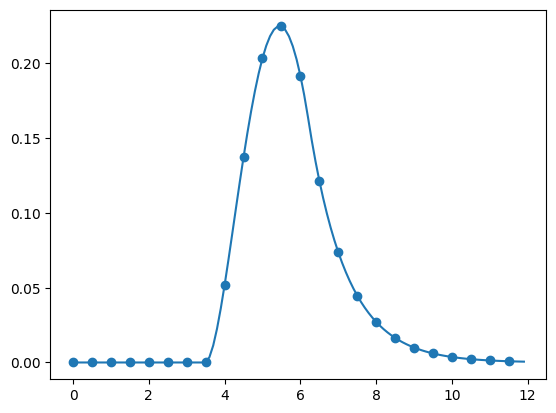

In [70]:
def firing_rate_threshold(t, data, T, I_ext, J):
    x = data[0]
    activation = np.maximum(0, I_ext(t)+J*x-T)
    return [-x + activation]

def I(t, t_peak, sigma):
    return 2.0 * np.exp(-((t - t_peak)**2) / (2 * sigma**2)) 
    
T_max = 12

sol = solve_ivp(
    firing_rate_threshold, 
    [0, T_max], (x0:=0.,), args=(1.5, lambda t: I(t, 5, 2), -1), t_eval=np.arange(0, T_max, 0.1),
    rtol = 1e-8, atol=1e-8)

plt.plot(sol.t, sol.y[0])

X_train = sol.y[0][::5]
T_train = sol.t[::5]

plt.scatter(T_train, X_train)

plt.show()

In [80]:
class learn_all(nn.Module):
    def __init__(self, J):
        super().__init__()

        self.J = J

        self.net_transfer = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

        self.net_impulse = nn.Sequential(
            nn.Linear(1, 16),
            nn.Tanh(),
            nn.Linear(16, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 16),
            nn.Tanh(),
            nn.Linear(16, 1),
            nn.Softplus()
        )


    def forward(self, t, x):
        return -x + self.net_transfer(self.net_impulse(t.reshape(1, 1)) + self.J * x )

In [ ]:
advanced_monkey = learn_all(
    torch.tensor([-1.]),
)

lr = 0.0003


optimizer = optim.Adam(advanced_monkey.parameters(), lr=lr)


n_epochs = 1000
rtol = 1e-7

t_train_torch = torch.tensor(T_train, dtype=torch.float32)
x0_torch = torch.tensor([x0], dtype=torch.float32, requires_grad=True)
x_train_torch = torch.tensor(X_train, dtype=torch.float32).view(-1, 1)
losses = []

for EPOCH in (range(n_epochs)):
    optimizer.zero_grad()
    
    # forward solution
    x_pred = odeint(advanced_monkey, 
                    x0_torch,
                    t_train_torch,
                    rtol=rtol
                    )
    
    # Compute loss at training points
    loss = torch.tensor(0., requires_grad=True)
    for i, (t, x_true) in enumerate(zip(T_train, X_train)):
        loss = loss + (x_pred[i] - x_true) ** 2
    
    loss = loss / len(T_train)
    
    # Backpropagate
    loss.backward()
    optimizer.step()

    print(f"{EPOCH}\t{loss.item():.7e}")
    losses.append(loss.item())


0	1.3617620e-02
1	1.3180636e-02
2	1.2757096e-02
3	1.2346957e-02
4	1.1950138e-02
5	1.1566483e-02
6	1.1195560e-02
7	1.0833364e-02
8	1.0471775e-02
9	1.0151145e-02
10	9.8642996e-03
11	9.5874537e-03
12	9.3206810e-03
13	9.0639433e-03
14	8.8171465e-03
15	8.5801408e-03
16	8.3459355e-03
17	8.1197815e-03
18	7.9027461e-03
19	7.6948819e-03
20	7.4961842e-03
21	7.3065958e-03
22	7.1260179e-03
23	6.9543249e-03
24	6.7913532e-03
25	6.6369246e-03
26	6.4908364e-03
27	6.3528679e-03
28	6.2227906e-03
29	6.1003589e-03
30	5.9847417e-03
31	5.8631990e-03
32	5.7460722e-03
33	5.6351381e-03
34	5.5310451e-03
35	5.4341033e-03
36	5.3444379e-03
37	5.2619781e-03
38	5.1865610e-03
39	5.1180073e-03
40	5.0560809e-03
41	5.0005126e-03
42	4.9509867e-03
43	4.9071717e-03
44	4.8687132e-03
45	4.8352494e-03
46	4.8064035e-03
47	4.7817999e-03
48	4.7610621e-03
49	4.7438191e-03
50	4.7297101e-03
51	4.7183814e-03
52	4.7094952e-03
53	4.7027292e-03
54	4.6980833e-03
55	4.6954770e-03
56	4.6933028e-03
57	4.6919971e-03
58	4.6914229e-03
59	4.69

In [91]:
torch.save(advanced_monkey.state_dict(), "./models_weights/monkey_2_followup.dinomeng")

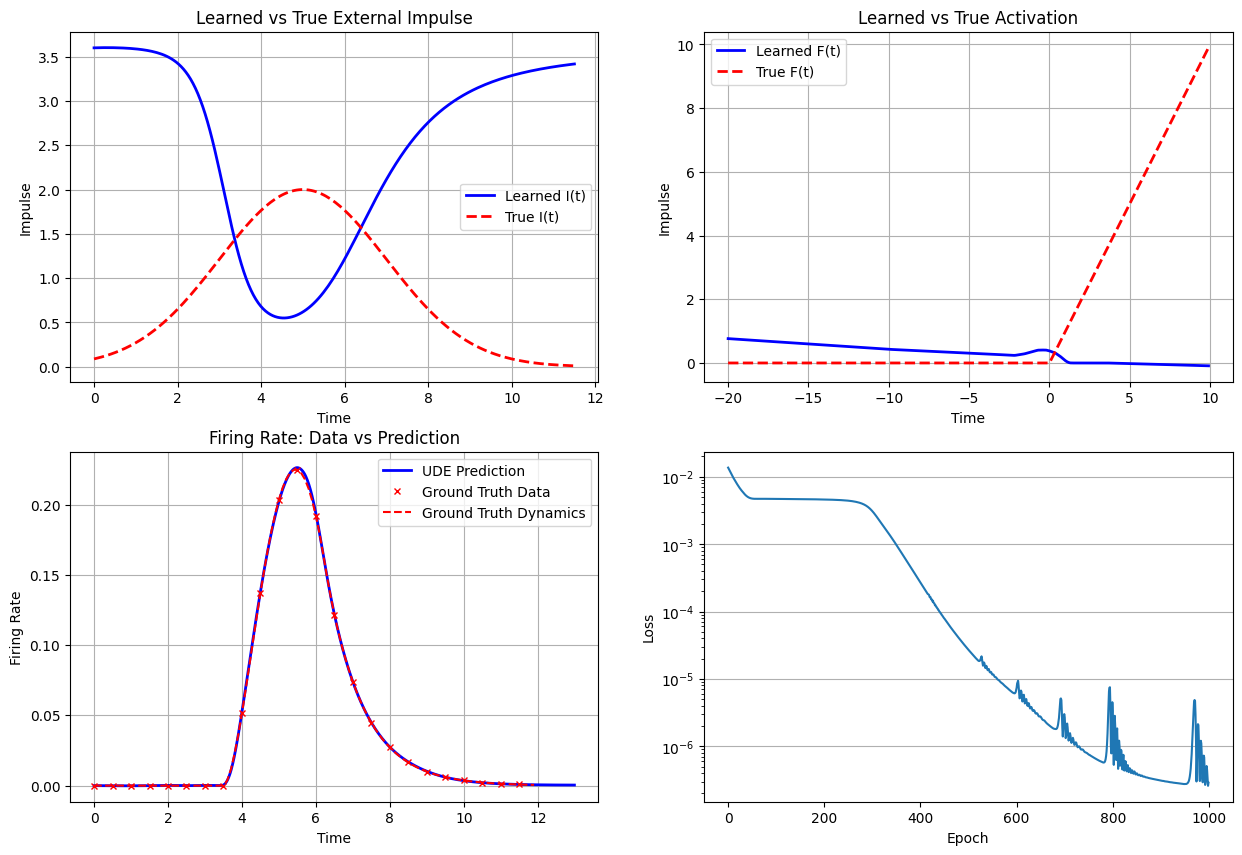

In [87]:
# Plot the learned impulse function
t_plot = torch.linspace(0, T_train[-1], 200)
with torch.no_grad():
    I_learned = torch.stack([advanced_monkey.net_impulse(torch.tensor([[t]], dtype=torch.float32)) 
                             for t in t_plot]).squeeze()

plt.figure(figsize=(15, 10))

# Plot 1: Learned impulse vs true impulse
plt.subplot(2, 2, 1)
plt.plot(t_plot.numpy(), I_learned.numpy(), 'b-', linewidth=2, label='Learned I(t)')
t_true = np.linspace(0, T_train[-1], 200)
I_true = np.array([I(t, 5, 2) for t in t_true])
plt.plot(t_true, I_true, 'r--', linewidth=2, label='True I(t)')
plt.xlabel('Time')
plt.ylabel('Impulse')
plt.legend()
plt.title('Learned vs True External Impulse')
plt.grid()

# Plot the transfer function
i_plot = torch.arange(-20, 10, 0.1)
with torch.no_grad():
    act_learned = torch.stack([advanced_monkey.net_transfer(torch.tensor([[I]], dtype=torch.float32)) 
                             for I in i_plot]).squeeze()

# Plot 2: Learned Activation vs true activation
plt.subplot(2, 2, 2)
plt.plot(i_plot.numpy(), act_learned.numpy(), 'b-', linewidth=2, label='Learned F(t)')

i_true = np.arange(-20, 10, 0.1)

act_true = np.maximum(0, i_true)

plt.plot(i_true, act_true, 'r--', linewidth=2, label='True F(t)')
plt.xlabel('Time')
plt.ylabel('Impulse')
plt.legend()
plt.title('Learned vs True Activation')
plt.grid()


# Plot 3: Predictions vs data
plt.subplot(2, 2, 3)
x_pred = odeint(advanced_monkey, 
                torch.tensor([X_train[0]], dtype=torch.float32).unsqueeze(1),
                T_eval := torch.arange(0,13, 0.01))
plt.plot(T_eval.detach().numpy(), x_pred.detach().numpy().squeeze(), 'b-', linewidth=2, label='UDE Prediction')
plt.plot(T_train, X_train, 'xr', markersize=4, label='Ground Truth Data')
plt.plot(sol.t, sol.y[0], 'r--', markersize=4, label='Ground Truth Dynamics')

plt.xlabel('Time')
plt.ylabel('Firing Rate')
plt.legend()
plt.title('Firing Rate: Data vs Prediction')
plt.grid()

# Plot 3: losses with semilogy
# NOTE: To obtain this data, I copied the output of the cell that printed the losses and processed it with regex to obtain a readable .csv file by the standards
losses_data = np.array(losses)


plt.subplot(2, 2, 4)
plt.semilogy(range((losses_data.shape[0])), losses_data)
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(axis='y')

plt.show()



weird, it still insists on the "inverse bell" shape

## Experiment 2: Optuna
The following code will be used as a "base" for the .py script

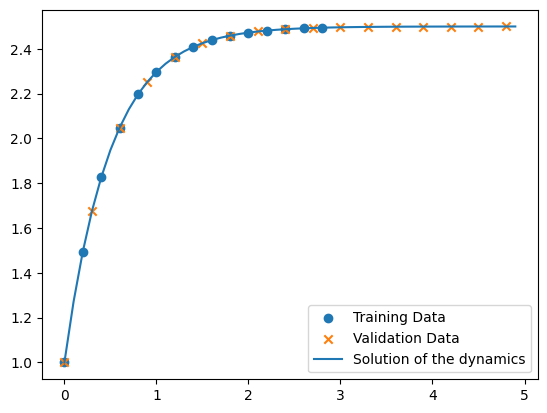

In [6]:
T_max = 5
def firing_rate_threshold(t, data, T, I_ext, J):
    x = data[0]
    activation = np.maximum(0, I_ext+J*x-T)
    return [-x + activation]

sol = solve_ivp(
    firing_rate_threshold, 
    [0, T_max], (x0 := 1.,), args=(1, 6, -1), t_eval=np.arange(0, T_max, 0.1),
    rtol = 1e-10, atol=1e-10)

X_train = sol.y[0][:30:2]
T_train = sol.t[:30:2]

X_val = sol.y[0][::3]
T_val = sol.t[::3]



plt.scatter(T_train, X_train, label="Training Data")
plt.scatter(T_val, X_val, label="Validation Data", marker="x")

plt.plot(np.arange(0, T_max, 0.1), sol.y[0], label="Solution of the dynamics")

plt.legend()

plt.show()

In [7]:
class learn_activation(nn.Module):
    def __init__(self, Iext, J):
        super().__init__()

        self.I_ext = Iext 
        self.J = J

        self.net = None 
        
    def forward(self, t, x):
        return -x + self.net(self.I_ext + self.J * x )

In [8]:
x0_torch = torch.tensor([x0], dtype=torch.float32, requires_grad=True)

t_train_torch = torch.tensor(T_train, dtype=torch.float32)
x_train_torch = torch.tensor(X_train, dtype=torch.float32).view(-1, 1)
t_val_torch = torch.tensor(T_val, dtype=torch.float32)
x_val_torch = torch.tensor(X_val, dtype=torch.float32).view(-1, 1)


In [10]:
import optuna

In [13]:
def objective(trial):
    # 2. Suggest values of the hyperparameters using a trial object.
    n_layers = trial.suggest_int('n_layers', 1, 5)
    layers = []

    in_features = 1
    for i in range(n_layers):
        out_features = trial.suggest_int(f'n_units_l{i}', 4, 128)
        activation = trial.suggest_categorical(name="activation",
            choices=[
                    "ReLU", "Tanh", "LeakyReLU", "SiLU", "Sigmoid"
                ]
        )

        activation = getattr(torch.nn, activation)()

        layers.append(torch.nn.Linear(in_features, out_features))
        layers.append(activation)
        in_features = out_features

    layers.append(torch.nn.Linear(in_features, 1))
    # layers.append(torch.nn.LogSoftmax(dim=1))

    model = learn_activation(6, -1)
    model.net = nn.Sequential(*layers)
    lr = 0.0003
    optimizer = optim.Adam(model.parameters(), lr=lr)

    epochs = 100
    for epoch in range(epochs):
        optimizer.zero_grad()
        
        # forward solution
        x_pred = odeint(model, 
                        x0_torch,
                        t_train_torch,
                        )
        
        # Compute loss at training points
        loss = torch.tensor(0., requires_grad=True)
        for i, (t, x_true) in enumerate(zip(T_train, X_train)):
            loss = loss + (x_pred[i] - x_true) ** 2
        
        loss = loss / len(T_train)
        
        # Backpropagate
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        x_pred = odeint(model, 
                    x0_torch,
                    t_val_torch,
                    )
        
        loss_val = torch.mean((x_pred-x_val_torch)**2)

    return loss_val

In [15]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=3, n_jobs=-1)

[I 2026-04-13 12:34:18,758] A new study created in memory with name: no-name-9f2358c6-cb42-4b23-9119-1dd5bd1780bc
[I 2026-04-13 12:34:36,061] Trial 2 finished with value: 0.5050454139709473 and parameters: {'n_layers': 1, 'n_units_l0': 52, 'activation': 'ReLU'}. Best is trial 2 with value: 0.5050454139709473.
[I 2026-04-13 12:34:38,194] Trial 0 finished with value: 0.15423503518104553 and parameters: {'n_layers': 2, 'n_units_l0': 37, 'activation': 'ReLU', 'n_units_l1': 52}. Best is trial 0 with value: 0.15423503518104553.
[I 2026-04-13 12:34:39,244] Trial 1 finished with value: 0.003459048690274358 and parameters: {'n_layers': 3, 'n_units_l0': 54, 'activation': 'LeakyReLU', 'n_units_l1': 51, 'n_units_l2': 39}. Best is trial 1 with value: 0.003459048690274358.


We found the best configuration: let's apply it

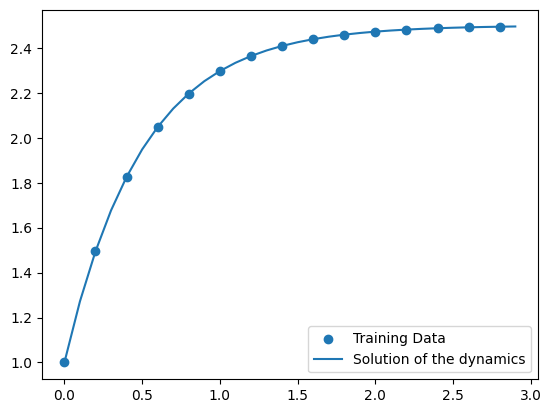

In [5]:
def firing_rate_threshold(t, data, T, I_ext, J):
    x = data[0]
    activation = np.maximum(0, I_ext+J*x-T)
    return [-x + activation]

T_max = 3

sol = solve_ivp(
    firing_rate_threshold, 
    [0, T_max], (1.,), args=(1, 6, -1), t_eval=np.arange(0, T_max, 0.1),
    rtol = 1e-10, atol=1e-10)

X_train = sol.y[0][::2]
T_train = sol.t[::2]

plt.scatter(T_train, X_train, label="Training Data")

plt.plot(np.arange(0, T_max, 0.1), sol.y[0], label="Solution of the dynamics")

plt.legend()

plt.show()

In [28]:
class learn_activation(nn.Module):
    def __init__(self, Iext, J):
        super().__init__()

        self.I_ext = Iext 
        self.J = J

        n_layers =2
        layers = []

        n_units = {
            0: 120, 
            1: 50
        }

        activations = {
            0: 'LeakyReLU',
            1: 'ReLU'
        }

        in_features = 1
        for i in range(n_layers):
            out_features = n_units[i]
            activation = activations[i]

            activation = getattr(torch.nn, activation)()

            layers.append(torch.nn.Linear(in_features, out_features))
            layers.append(activation)
            in_features = out_features

        layers.append(torch.nn.Linear(in_features, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, t, x):
        return -x + self.net(self.I_ext + self.J * x )

In [29]:
monkey_reaction = learn_activation(
     torch.tensor([6.]), torch.tensor([-1.])
)

lr = 0.004
optimizer = optim.Adam(monkey_reaction.parameters(), lr=lr)
losses = []
n_epochs = 2000
rtol = 1e-7

t_train_torch = torch.tensor(T_train)

for EPOCH in (range(n_epochs)):
    optimizer.zero_grad()
    monkey_reaction.zero_grad()
    
    # forward solution
    x_pred = odeint(monkey_reaction, 
                    torch.tensor([1.], requires_grad=False),
                    t_train_torch,
                    rtol=rtol
                    )
    
    # Compute loss at training points
    loss = torch.tensor(0., requires_grad=True)
    for i, (t, x_true) in enumerate(zip(T_train, X_train)):
        loss = loss + (x_pred[i] - x_true) ** 2
    
    loss = loss / len(T_train)
    
    # Backpropagate
    loss.backward()
    optimizer.step()
    
    print(f"{EPOCH}\t{loss.item():.4e}")
    losses.append(loss.item())


0	3.1989e+00
1	1.3138e+00
2	4.5889e-01
3	9.8107e-02
4	1.5575e-03
5	4.8382e-02
6	1.4615e-01
7	2.3686e-01
8	2.9732e-01
9	3.2573e-01
10	3.3262e-01
11	3.1275e-01
12	2.7307e-01
13	2.2118e-01
14	1.6447e-01
15	1.0977e-01
16	6.2813e-02
17	2.7816e-02
18	7.0680e-03
19	6.7085e-04
20	6.5070e-03
21	2.0523e-02
22	3.7501e-02
23	5.2394e-02
24	6.1672e-02
25	6.3901e-02
26	5.9512e-02
27	5.0188e-02
28	3.9310e-02
29	2.8019e-02
30	1.7420e-02
31	8.9142e-03
32	3.3172e-03
33	8.1779e-04
34	1.0545e-03
35	3.2718e-03
36	6.5200e-03
37	9.8541e-03
38	1.2497e-02
39	1.3945e-02
40	1.4005e-02
41	1.2781e-02
42	1.0601e-02
43	7.9263e-03
44	5.2460e-03
45	2.9833e-03
46	1.4250e-03
47	6.8519e-04
48	7.0639e-04
49	1.2946e-03
50	2.1773e-03
51	3.0696e-03
52	3.7352e-03
53	4.0286e-03
54	3.9115e-03
55	3.4434e-03
56	2.7533e-03
57	2.0001e-03
58	1.3320e-03
59	8.5635e-04
60	6.2172e-04
61	6.1691e-04
62	7.8340e-04
63	1.0361e-03
64	1.2864e-03
65	1.4632e-03
66	1.5257e-03
67	1.4670e-03
68	1.3113e-03
69	1.1019e-03
70	8.8877e-04
71	7.1478e-04
72

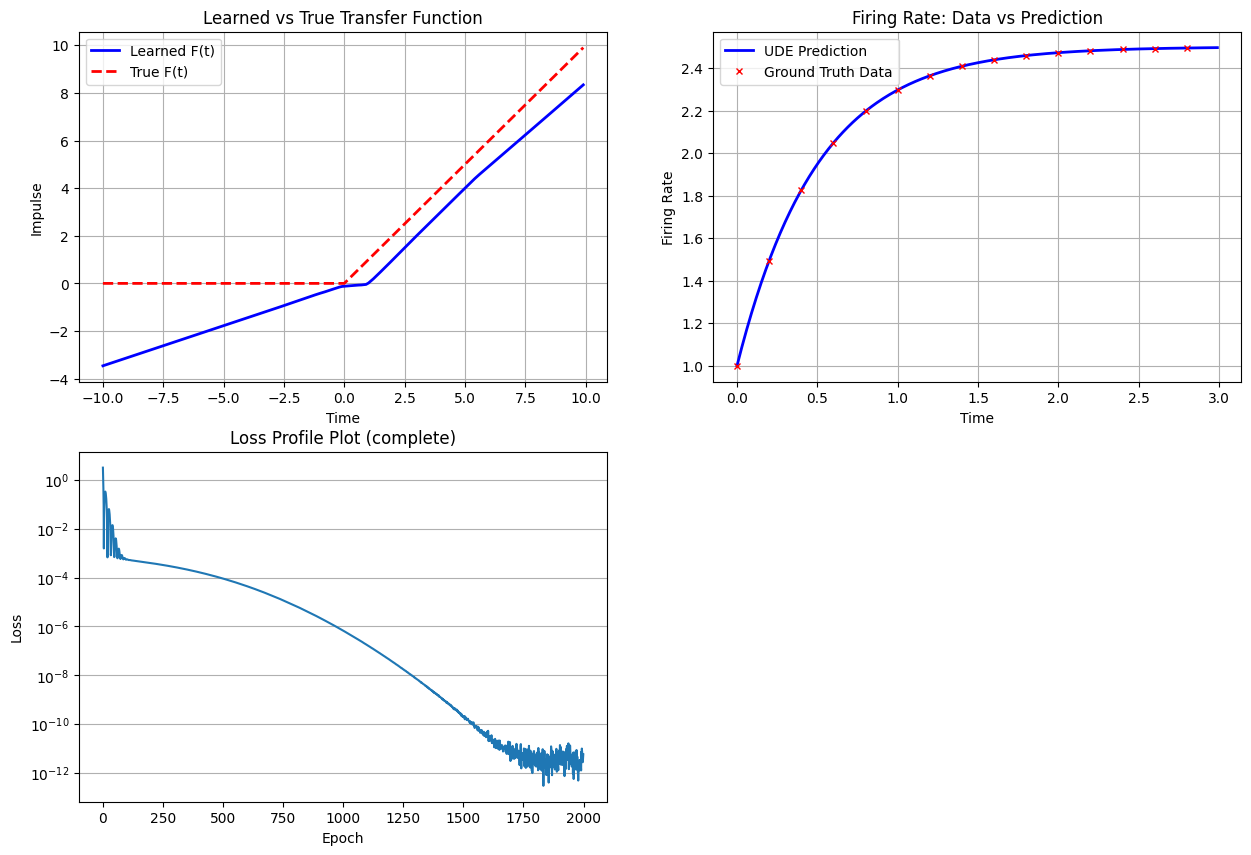

In [30]:
# Plot the transfer function
i_plot = torch.arange(-10, 10, 0.1)
with torch.no_grad():
    act_learned = torch.stack([monkey_reaction.net(torch.tensor([[I]], dtype=torch.float32)) 
                             for I in i_plot]).squeeze()

plt.figure(figsize=(15, 10))

# Plot 1: Learned Activation vs true activation
plt.subplot(2, 2, 1)
plt.plot(i_plot.numpy(), act_learned.numpy(), 'b-', linewidth=2, label='Learned F(t)')

i_true = np.arange(-10, 10, 0.1)

act_true = np.maximum(0, i_true)

plt.plot(i_true, act_true, 'r--', linewidth=2, label='True F(t)')
plt.xlabel('Time')
plt.ylabel('Impulse')
plt.legend()
plt.title('Learned vs True Transfer Function')
plt.grid()

# Plot 2: Predictions vs data
plt.subplot(2, 2, 2)
x_pred = odeint(monkey_reaction, 
                torch.tensor([X_train[0]], dtype=torch.float32).unsqueeze(1),
                T_eval := torch.arange(0,3, 0.01))

plt.plot(T_eval.detach().numpy(), x_pred.detach().numpy().squeeze(), 'b-', linewidth=2, label='UDE Prediction')
plt.plot(T_train, X_train, 'xr', markersize=4, label='Ground Truth Data')

plt.xlabel('Time')
plt.ylabel('Firing Rate')
plt.legend()
plt.title('Firing Rate: Data vs Prediction')
plt.grid()

# Plot 3: losses with semilogy
losses_data = np.array(losses)

plt.subplot(2, 2, 3)
plt.semilogy(range((losses_data.shape[0])), losses_data)
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss Profile Plot (complete)")
plt.grid(axis='y')

plt.show()

